<a href="https://colab.research.google.com/github/balkiss06/Water_potability/blob/main/water.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WATER QUALITY**
---
---
---





### *Author: Balkis Joudi*
**LinkedIn:** https://www.linkedin.com/in/balkis-joudi-332076328/

---
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## ***EDA***

---


In [2]:
d=pd.read_csv("/content/drive/MyDrive/formation/water_potability.csv")
print(d)

            ph    Hardness        Solids  Chloramines     Sulfate  \
0          NaN  204.890455  20791.318981     7.300212  368.516441   
1     3.716080  129.422921  18630.057858     6.635246         NaN   
2     8.099124  224.236259  19909.541732     9.275884         NaN   
3     8.316766  214.373394  22018.417441     8.059332  356.886136   
4     9.092223  181.101509  17978.986339     6.546600  310.135738   
...        ...         ...           ...          ...         ...   
3271  4.668102  193.681735  47580.991603     7.166639  359.948574   
3272  7.808856  193.553212  17329.802160     8.061362         NaN   
3273  9.419510  175.762646  33155.578218     7.350233         NaN   
3274  5.126763  230.603758  11983.869376     6.303357         NaN   
3275  7.874671  195.102299  17404.177061     7.509306         NaN   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       564.308654       10.379783        86.990970   2.963135           0  
1       592.88535

In [3]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
d.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [5]:
print(d.columns)

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


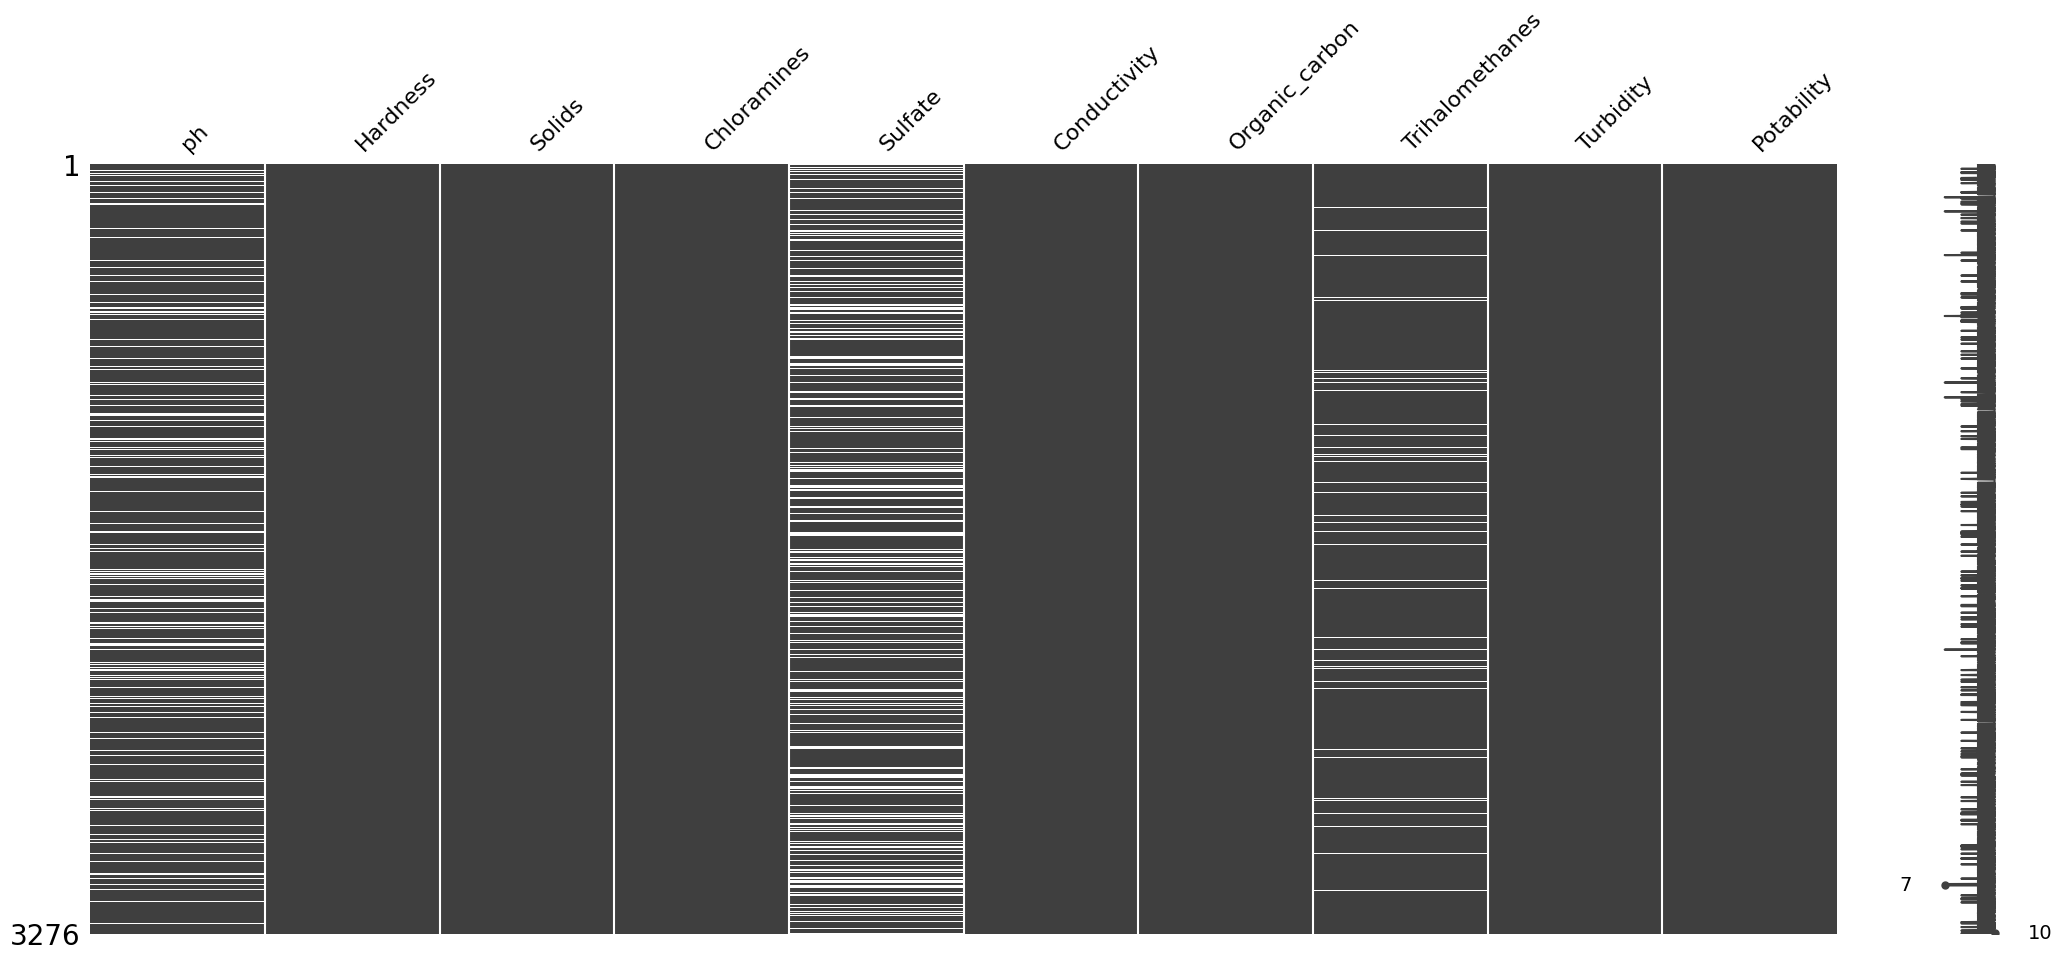

In [6]:
print(d.isnull().sum())
msno.matrix(d)
plt.show()

In [7]:
print(d.duplicated().sum())

0


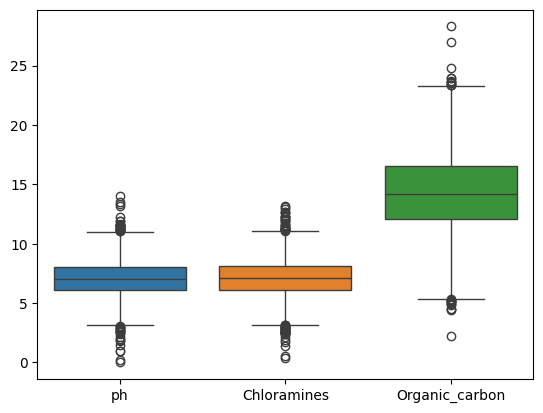

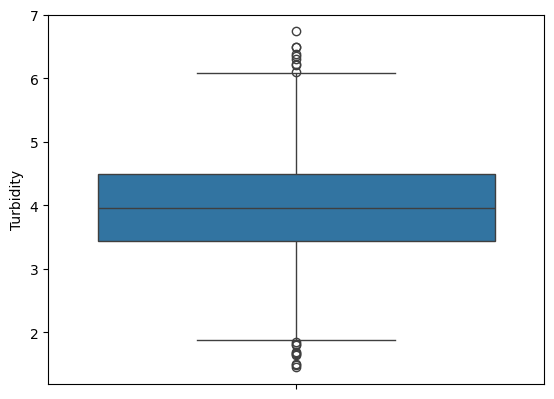

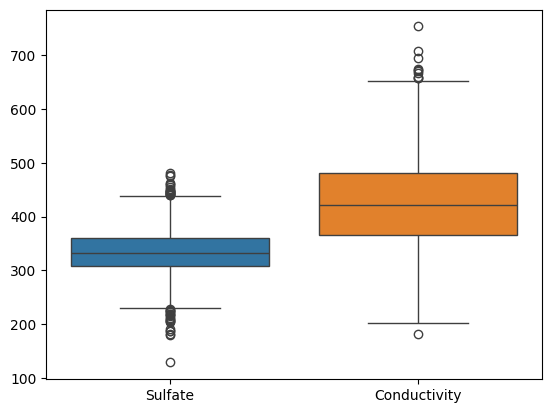

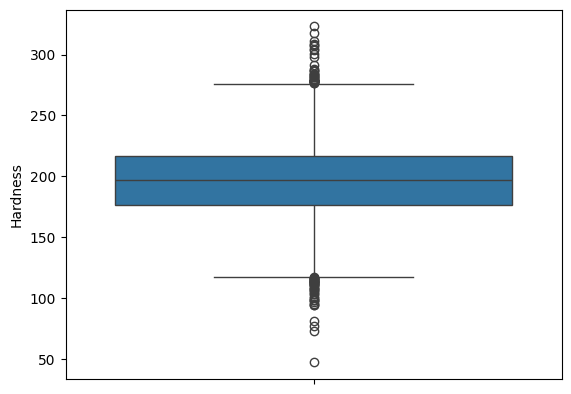

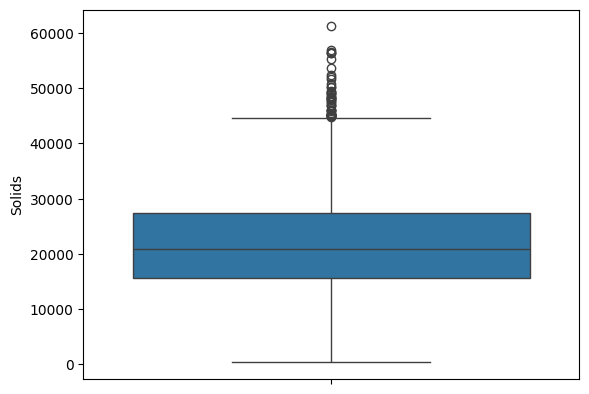

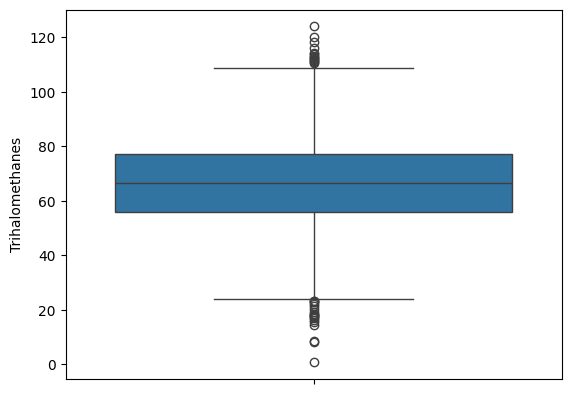

In [8]:
sns.boxplot(d[["ph","Chloramines","Organic_carbon"]])
plt.show()
sns.boxplot(d["Turbidity"])
plt.show()
sns.boxplot(d[["Sulfate","Conductivity"]])
plt.show()
sns.boxplot(d["Hardness"])
plt.show()
sns.boxplot(d["Solids"])
plt.show()
sns.boxplot(d["Trihalomethanes"])
plt.show()

                       ph  Hardness    Solids  Chloramines   Sulfate  \
ph               1.000000  0.082096 -0.089288    -0.034350  0.018203   
Hardness         0.082096  1.000000 -0.046899    -0.030054 -0.106923   
Solids          -0.089288 -0.046899  1.000000    -0.070148 -0.171804   
Chloramines     -0.034350 -0.030054 -0.070148     1.000000  0.027244   
Sulfate          0.018203 -0.106923 -0.171804     0.027244  1.000000   
Conductivity     0.018614 -0.023915  0.013831    -0.020486 -0.016121   
Organic_carbon   0.043503  0.003610  0.010242    -0.012653  0.030831   
Trihalomethanes  0.003354 -0.013013 -0.009143     0.017084 -0.030274   
Turbidity       -0.039057 -0.014449  0.019546     0.002363 -0.011187   
Potability      -0.003556 -0.013837  0.033743     0.023779 -0.023577   

                 Conductivity  Organic_carbon  Trihalomethanes  Turbidity  \
ph                   0.018614        0.043503         0.003354  -0.039057   
Hardness            -0.023915        0.003610        

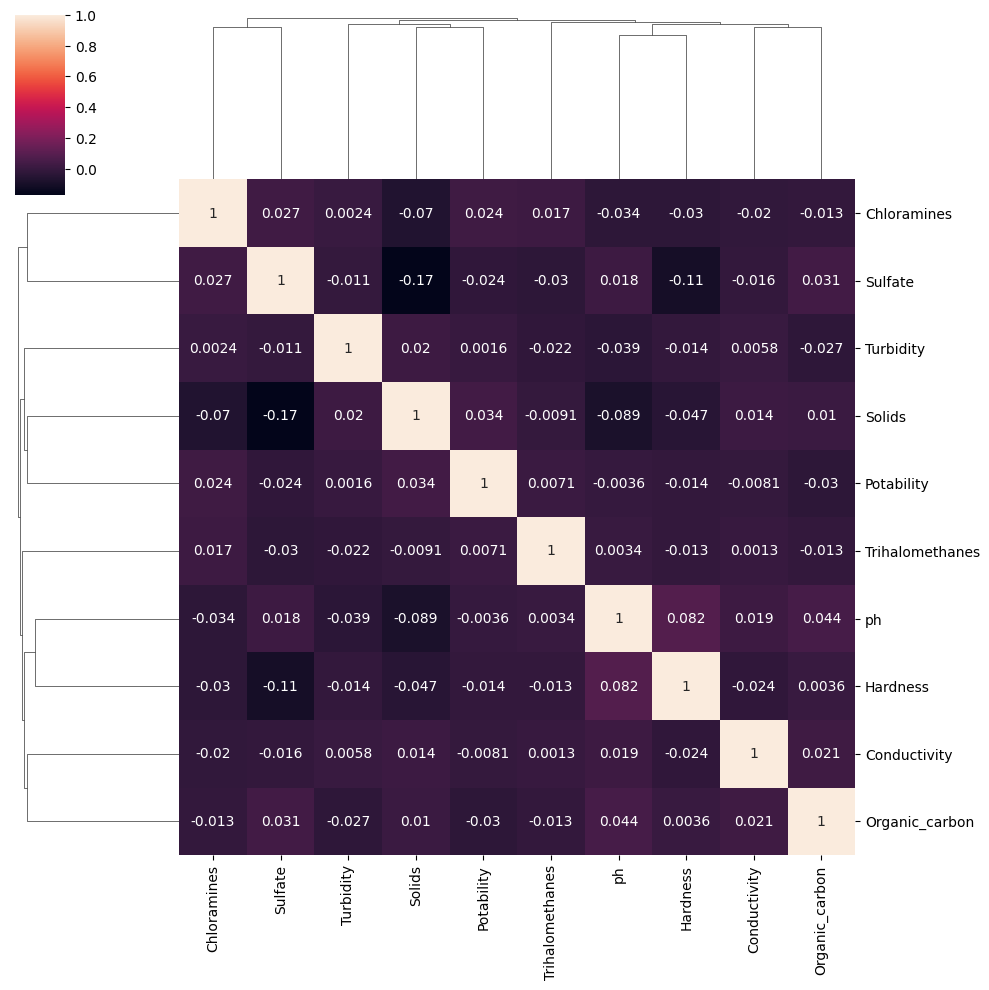

In [9]:
print(d.corr())
sns.clustermap(d.corr(),annot = True)
plt.show()

Potability
0    1998
1    1278
Name: count, dtype: int64


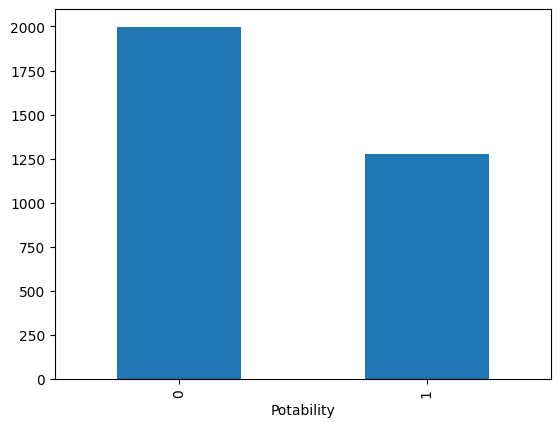

In [10]:
print(d["Potability"].value_counts())
d["Potability"].value_counts().plot(kind="bar")
plt.show()

# ***PRETRAITEMENT***


---



In [11]:
d["ph"].fillna(d["ph"].median(),inplace=True)
print(d["ph"].median())
print(d["ph"])

7.036752103833548
0       7.036752
1       3.716080
2       8.099124
3       8.316766
4       9.092223
          ...   
3271    4.668102
3272    7.808856
3273    9.419510
3274    5.126763
3275    7.874671
Name: ph, Length: 3276, dtype: float64


/tmp/ipykernel_741/2921873202.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["ph"].fillna(d["ph"].median(),inplace=True)


In [12]:
d["Sulfate"].fillna(d["Sulfate"].median(),inplace=True)
print(d["Sulfate"].median())
print(d["Sulfate"])

333.073545745888
0       368.516441
1       333.073546
2       333.073546
3       356.886136
4       310.135738
           ...    
3271    359.948574
3272    333.073546
3273    333.073546
3274    333.073546
3275    333.073546
Name: Sulfate, Length: 3276, dtype: float64


/tmp/ipykernel_741/3598762973.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["Sulfate"].fillna(d["Sulfate"].median(),inplace=True)


In [13]:
d["Trihalomethanes"].fillna(d["Trihalomethanes"].median(),inplace=True)
print(d["Trihalomethanes"].median())
print(d["Trihalomethanes"])

66.62248509808484
0        86.990970
1        56.329076
2        66.420093
3       100.341674
4        31.997993
           ...    
3271     66.687695
3272     66.622485
3273     69.845400
3274     77.488213
3275     78.698446
Name: Trihalomethanes, Length: 3276, dtype: float64


/tmp/ipykernel_741/2257651939.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d["Trihalomethanes"].fillna(d["Trihalomethanes"].median(),inplace=True)


# ***SEPARARTION DES DONNEES***

---


In [14]:
x = d.drop('Potability', axis=1)
y = d['Potability']
print(x.shape, y.shape)

(3276, 9) (3276,)


In [15]:
s=StandardScaler()
x=s.fit_transform(x)
print(x)

[[-2.54735465e-02  2.59194711e-01 -1.39470871e-01 ... -1.18065057e+00
   1.30543373e+00 -1.28629758e+00]
 [-2.28471739e+00 -2.03641367e+00 -3.85986650e-01 ...  2.70597240e-01
  -6.39186284e-01  6.84217891e-01]
 [ 6.97319183e-01  8.47664833e-01 -2.40047337e-01 ...  7.81116857e-01
   8.00012586e-04 -1.16736546e+00]
 ...
 [ 1.59565368e+00 -6.26829230e-01  1.27080989e+00 ... -9.81329234e-01
   2.18037800e-01 -8.56006782e-01]
 [-1.32494885e+00  1.04135450e+00 -1.14405809e+00 ... -9.42063817e-01
   7.02755628e-01  9.50797383e-01]
 [ 5.44611034e-01 -3.85462310e-02 -5.25811937e-01 ...  5.60940070e-01
   7.79510303e-01 -2.12445866e+00]]


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(y_train.value_counts())
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
sm=SMOTE()
x_train, y_train = sm.fit_resample(x_train, y_train)
print(y_train.value_counts())

Potability
0    1586
1    1034
Name: count, dtype: int64
(2620, 9) (2620,)
(656, 9) (656,)
Potability
0    1586
1    1586
Name: count, dtype: int64


# **MODELE DU MACHINE LEARNING**


---



In [17]:
model=RandomForestClassifier()

In [18]:
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,

# **EVALUATION**


---



In [19]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)
print(classification_report(y_test, y_pred))

0.6463414634146342
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       412
           1       0.53      0.47      0.50       244

    accuracy                           0.65       656
   macro avg       0.62      0.61      0.61       656
weighted avg       0.64      0.65      0.64       656



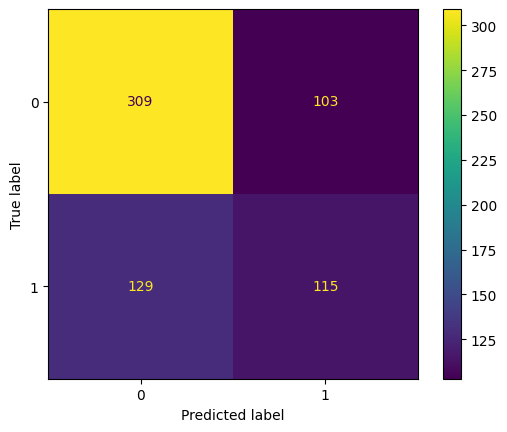

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

# **TEST**

---



In [21]:
w=pd.DataFrame([{
    'ph':7.080795,
    'Hardness': 196.369497,
    'Solids': 22014.092526,
    'Chloramines': 7.122277,
    'Sulfate': 333.775777,
    'Conductivity': 426.205111,
    'Organic_carbon': 14.284970,
    'Trihalomethanes': 66.396293,
    'Turbidity': 3.966786
}])
print(w)
w=s.fit_transform(w)
prediction = model.predict(w)
print(prediction)

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0  7.080795  196.369497  22014.092526     7.122277  333.775777    426.205111   

   Organic_carbon  Trihalomethanes  Turbidity  
0        14.28497        66.396293   3.966786  
[0]


# **Autre** **modèle**

---



0.6265243902439024
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       412
           1       0.50      0.52      0.51       244

    accuracy                           0.63       656
   macro avg       0.60      0.61      0.60       656
weighted avg       0.63      0.63      0.63       656



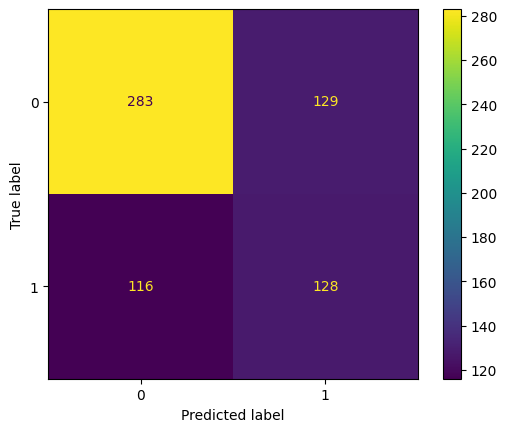

In [22]:
!pip install xgboost
from xgboost import XGBClassifier
xg= XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,)
xg.fit(x_train, y_train)
y_pred = xg.predict(x_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()